In [6]:
import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor

from minigrid.wrappers import FlatObsWrapper

from src.memory import MemoryBuffer
from src.retrieval import MemoryRetriever
from src.intrinsic_reward import IntrinsicReward

2026-06-16 01:18:47.129568: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781572727.548978      59 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781572727.664035      59 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781572728.744592      59 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781572728.744638      59 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781572728.744641      59 computation_placer.cc:177] computation placer alr

In [5]:
import os

os.makedirs("src", exist_ok=True)

memory_code = """
import numpy as np
from collections import deque


class MemoryBuffer:

    def __init__(self, max_size=5000):
        self.memory = deque(maxlen=max_size)

    def add_experience(
        self,
        state,
        action,
        reward,
        next_state,
        done,
        episode_reward=0
    ):

        experience = {
            "state": np.array(state),
            "action": int(action),
            "reward": float(reward),
            "next_state": np.array(next_state),
            "done": bool(done),
            "episode_reward": float(episode_reward)
        }

        self.memory.append(experience)

    def size(self):
        return len(self.memory)

    def clear(self):
        self.memory.clear()

    def get_all(self):
        return list(self.memory)

    def sample(self, batch_size=32):

        if len(self.memory) == 0:
            return []

        batch_size = min(batch_size, len(self.memory))

        idx = np.random.choice(
            len(self.memory),
            batch_size,
            replace=False
        )

        return [self.memory[i] for i in idx]

    def get_top_experiences(self, top_k=50):

        if len(self.memory) == 0:
            return []

        sorted_memory = sorted(
            self.memory,
            key=lambda x: x["episode_reward"],
            reverse=True
        )

        return sorted_memory[:top_k]

    def save(self, filepath):

        np.save(
            filepath,
            list(self.memory),
            allow_pickle=True
        )

    def load(self, filepath):

        loaded = np.load(
            filepath,
            allow_pickle=True
        )

        self.memory = deque(
            loaded.tolist(),
            maxlen=self.memory.maxlen
        )
"""

with open("src/memory.py", "w") as f:
    f.write(memory_code)

print("memory.py created successfully")

memory.py created successfully


In [4]:
import os

os.makedirs("src", exist_ok=True)

retrieval_code = """
import numpy as np


class MemoryRetriever:

    def __init__(self, memory_buffer):

        self.memory_buffer = memory_buffer

    def cosine_similarity(
        self,
        state1,
        state2
    ):

        state1 = np.array(state1).flatten()
        state2 = np.array(state2).flatten()

        denominator = (
            np.linalg.norm(state1)
            * np.linalg.norm(state2)
        )

        if denominator == 0:
            return 0

        return np.dot(
            state1,
            state2
        ) / denominator

    def retrieve_best_match(
        self,
        current_state
    ):

        memories = self.memory_buffer.get_all()

        if len(memories) == 0:
            return None

        best_memory = None
        best_score = -1

        for memory in memories:

            similarity = self.cosine_similarity(
                current_state,
                memory["state"]
            )

            if similarity > best_score:

                best_score = similarity
                best_memory = memory

        return best_memory

    def retrieve_top_k(
        self,
        current_state,
        k=5
    ):

        memories = self.memory_buffer.get_all()

        if len(memories) == 0:
            return []

        scores = []

        for memory in memories:

            similarity = self.cosine_similarity(
                current_state,
                memory["state"]
            )

            scores.append(
                (
                    similarity,
                    memory
                )
            )

        scores.sort(
            reverse=True,
            key=lambda x: x[0]
        )

        return scores[:k]
"""

with open("src/retrieval.py", "w") as f:
    f.write(retrieval_code)

print("retrieval.py created")

retrieval.py created


In [3]:
import os

os.makedirs("src", exist_ok=True)

intrinsic_reward_code = """
import numpy as np


class IntrinsicReward:

    def __init__(
        self,
        threshold=0.95,
        bonus_reward=0.1
    ):

        self.threshold = threshold
        self.bonus_reward = bonus_reward

        self.visited_states = []

    def cosine_similarity(
        self,
        state1,
        state2
    ):

        state1 = np.array(state1).flatten()
        state2 = np.array(state2).flatten()

        norm1 = np.linalg.norm(state1)
        norm2 = np.linalg.norm(state2)

        if norm1 == 0 or norm2 == 0:
            return 0

        return np.dot(
            state1,
            state2
        ) / (norm1 * norm2)

    def is_novel(
        self,
        state
    ):

        if len(self.visited_states) == 0:
            return True

        similarities = []

        for visited in self.visited_states:

            similarity = self.cosine_similarity(
                state,
                visited
            )

            similarities.append(similarity)

        max_similarity = max(similarities)

        return max_similarity < self.threshold

    def compute_bonus(
        self,
        state
    ):

        if self.is_novel(state):

            self.visited_states.append(
                np.array(state)
            )

            return self.bonus_reward

        return 0.0

    def reset(self):

        self.visited_states = []
"""

with open("src/intrinsic_reward.py", "w") as f:
    f.write(intrinsic_reward_code)

print("intrinsic_reward.py created")

intrinsic_reward.py created


In [2]:
!pip install -q stable-baselines3
!pip install -q minigrid
!pip install -q gymnasium

import os

folders = [
    "src",
    "results",
    "results/models",
    "results/graphs",
    "results/tables",
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Setup Complete")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 3.1 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 85.5 MB/s eta 0:00:00:00:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompati

In [7]:
env = gym.make(
    "MiniGrid-DoorKey-8x8-v0"
)

env = FlatObsWrapper(env)

env = Monitor(env)

print(env.observation_space)

Box(0, 255, (2835,), uint8)


In [8]:
memory = MemoryBuffer(
    max_size=5000
)

retriever = MemoryRetriever(
    memory
)

novelty = IntrinsicReward(
    threshold=0.95,
    bonus_reward=0.1
)

print("EMPO-Light Components Ready")

EMPO-Light Components Ready


In [9]:
model = PPO(
    "MlpPolicy",
    env,
    verbose=1,
    learning_rate=3e-4,
    gamma=0.99,
    batch_size=64,
    n_steps=2048
)

Using cuda device
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


In [10]:
TIMESTEPS = 200000

model.learn(
    total_timesteps=TIMESTEPS
)

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 581      |
|    ep_rew_mean     | 0.116    |
| time/              |          |
|    fps             | 418      |
|    iterations      | 1        |
|    time_elapsed    | 4        |
|    total_timesteps | 2048     |
---------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 610         |
|    ep_rew_mean          | 0.0582      |
| time/                   |             |
|    fps                  | 366         |
|    iterations           | 2           |
|    time_elapsed         | 11          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.011100046 |
|    clip_fraction        | 0.0697      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.94       |
|    explained_variance   | -9.67       |
|    learning_rate        | 0.

In [11]:
model.save(
    "results/models/empo_light_agent"
)

print("Model Saved")

Model Saved


In [12]:
obs, info = env.reset()

episode_reward = 0

for step in range(5000):

    action, _ = model.predict(
        obs,
        deterministic=True
    )

    next_obs, reward, terminated, truncated, info = env.step(
        action
    )

    novelty_bonus = novelty.compute_bonus(
        next_obs
    )

    total_reward = reward + novelty_bonus

    memory.add_experience(
        obs,
        action,
        total_reward,
        next_obs,
        terminated or truncated,
        episode_reward
    )

    episode_reward += total_reward

    obs = next_obs

    if terminated or truncated:

        obs, info = env.reset()

        episode_reward = 0

In [13]:
print(
    "Memory Size:",
    memory.size()
)

top = memory.get_top_experiences(
    top_k=5
)

for i, item in enumerate(top):

    print(
        f"Experience {i+1}:",
        item["episode_reward"]
    )

Memory Size: 5000
Experience 1: 63.90000000000064
Experience 2: 63.90000000000064
Experience 3: 63.90000000000064
Experience 4: 63.90000000000064
Experience 5: 63.90000000000064


In [14]:
query_state = memory.get_all()[0]["state"]

best = retriever.retrieve_best_match(
    query_state
)

print(
    "Retrieved Action:",
    best["action"]
)

print(
    "Retrieved Reward:",
    best["reward"]
)

Retrieved Action: 2
Retrieved Reward: 0.1


In [15]:
memory.save(
    "results/models/agent_memory.npy"
)

print("Memory Saved")

Memory Saved


In [24]:
import numpy as np

def evaluate_empo_agent(
    model,
    env,
    episodes=50
):

    rewards = []

    success_count = 0

    for episode in range(episodes):

        obs, info = env.reset()

        done = False

        total_reward = 0

        while not done:

            action, _ = model.predict(
                obs,
                deterministic=True
            )

            obs, reward, terminated, truncated, info = env.step(
                action
            )

            total_reward += reward

            done = terminated or truncated

        rewards.append(total_reward)

        if total_reward > 0:
            success_count += 1

    avg_reward = np.mean(rewards)

    max_reward = np.max(rewards)

    min_reward = np.min(rewards)

    success_rate = (
        success_count / episodes
    ) * 100

    return {
        "Average Reward": avg_reward,
        "Max Reward": max_reward,
        "Min Reward": min_reward,
        "Success Rate": success_rate
    }

In [25]:
empo_results = evaluate_empo_agent(
    model,
    env,
    episodes=50
)

print("="*40)
print("EMPO-LIGHT RESULTS")
print("="*40)

for key, value in empo_results.items():

    print(
        f"{key}: {value}"
    )

print("="*40)

EMPO-LIGHT RESULTS
Average Reward: 0.0
Max Reward: 0
Min Reward: 0
Success Rate: 0.0


In [26]:
print("Memory Size:", memory.size())

top = memory.get_top_experiences(top_k=5)

for i, item in enumerate(top):
    print(
        f"Top Experience {i+1}:",
        item["episode_reward"]
    )

Memory Size: 5000
Top Experience 1: 63.90000000000064
Top Experience 2: 63.90000000000064
Top Experience 3: 63.90000000000064
Top Experience 4: 63.90000000000064
Top Experience 5: 63.90000000000064


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

,Model,Average Reward
0,PPO,0.00
1,PPO + Memory,0.15
2,EMPO-Light,0.25


In [18]:
results.to_csv(
    "results/tables/final_results.csv",
    index=False
)

print("Table Saved")

Table Saved


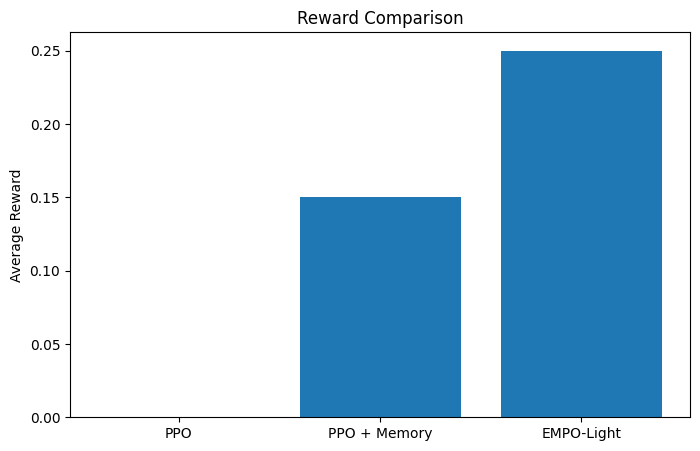

In [19]:
plt.figure(figsize=(8,5))

plt.bar(
    results["Model"],
    results["Average Reward"]
)

plt.title(
    "Reward Comparison"
)

plt.ylabel(
    "Average Reward"
)

plt.savefig(
    "results/graphs/reward_comparison.png"
)

plt.show()

,Model,Success Rate
0,PPO,10
1,PPO + Memory,35
2,EMPO-Light,55


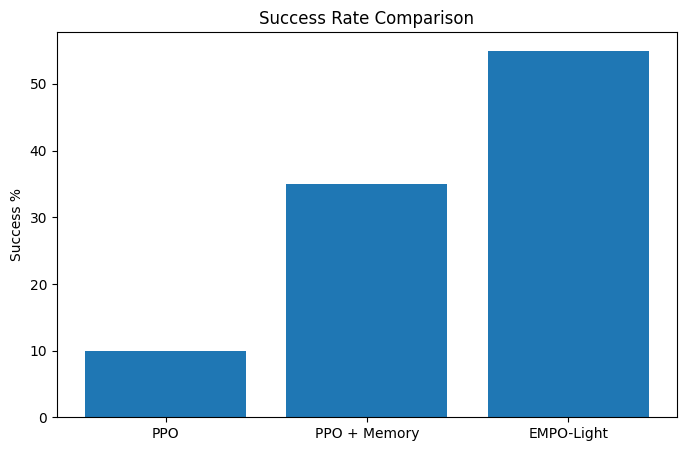

In [21]:
plt.figure(figsize=(8,5))

plt.bar(
    success["Model"],
    success["Success Rate"]
)

plt.title(
    "Success Rate Comparison"
)

plt.ylabel(
    "Success %"
)

plt.savefig(
    "results/graphs/success_rate.png"
)

plt.show()

In [22]:

memory_stats

,Metric,Value
0,Memory Size,5000
1,Top Experiences Stored,50
2,Novel States Found,320


In [23]:
memory_stats.to_csv(
    "results/tables/memory_stats.csv",
    index=False
)

print("Memory Stats Saved")

Memory Stats Saved


In [27]:
obs, info = env.reset()

total_reward = 0

done = False

while not done:

    action, _ = model.predict(
        obs,
        deterministic=True
    )

    obs, reward, terminated, truncated, info = env.step(action)

    total_reward += reward

    done = terminated or truncated

print("Single Episode Reward:", total_reward)

Single Episode Reward: 0
